# Posterior for local recombination rate using SBI + regression for summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.gam.api import GLMGam, BSplines
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from discrete_uniform import DiscreteUniform
from evaluate_posterior_metrics import evaluate_posterior_metrics

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

Load genome data and clonal tree.

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(30, 1000000)

In [4]:
np.random.seed(100)
clonal_tree = ClonalTree(n=30)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                    ____ 14
                                                                   |
                                                                   |    , 15
                                                        ___________|   _|
                                                       |           |  | , 5
                                                       |           |  | |
                                                       |           |__| | 24
                                                       |              |
                                                       |              | , 27
                                                       |              |_|
                                                       |                | 4
                                                       |
                                                       |      __________ 18
                                             

## Summary statistics

### Get summary statistics from SimBac data

In [5]:
x_500_SB = np.loadtxt("../data/x_500_SB.csv", delimiter=",")
x_2000_SB = np.loadtxt("../data/x_2000_SB.csv", delimiter=",")
x_6000_SB = np.loadtxt("../data/x_6000_SB.csv", delimiter=",")

x_500_SB.shape, x_2000_SB.shape, x_6000_SB.shape

((100, 46), (100, 46), (100, 46))

### Load simulations from ClonalOrigin model

In [6]:
x_500_CO = np.loadtxt("../data/x_500_CO.csv", delimiter=",")
x_2000_CO = np.loadtxt("../data/x_2000_CO.csv", delimiter=",")
x_6000_CO = np.loadtxt("../data/x_6000_CO.csv", delimiter=",")

x_500_CO.shape, x_2000_CO.shape, x_6000_CO.shape

((100, 46), (100, 46), (100, 46))

In [7]:
theta1 = np.loadtxt('../data/ClonalOrigin_rho/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/ClonalOrigin_rho/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/ClonalOrigin_rho/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/ClonalOrigin_rho/x2.csv', delimiter=",")

x = np.vstack([x1, x2])
theta = np.vstack([theta1, theta2])

print(theta.shape, x.shape)

(20000, 2) (20000, 46)


In [8]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Load summary table

In [9]:
df = pd.read_csv('../output/sbi_metric_table.csv')
df

,Method,Observations,rho_coverage,rho_bias,rho_variance,rho_relative_bias,rho_relative_RMSE,theta_coverage,theta_bias,theta_variance,theta_relative_bias,theta_relative_RMSE,L_coverage,L_bias,L_variance,L_relative_bias,L_relative_RMSE
0,1D_exact,SimBac500,0.91,0.006465,0.000069,0.193370,0.548253,NaN,NaN,NaN,NaN,NaN,0.95,24.299941,5021.258296,0.045493,0.120959
1,1D_exact,SimBac2000,0.95,0.002993,0.000022,0.030069,0.290708,NaN,NaN,NaN,NaN,NaN,1.00,13.326463,2584.612550,0.006484,0.020830
2,1D_exact,SimBac6000,0.94,0.002222,0.000006,0.014863,0.177471,NaN,NaN,NaN,NaN,NaN,0.95,8.354194,856.144312,-0.000268,0.003262
3,1D_exact,ClonalOrigin500,0.86,0.008184,0.000090,0.264956,0.648717,NaN,NaN,NaN,NaN,NaN,1.00,21.327362,6963.012476,0.037745,0.130308
4,1D_exact,ClonalOrigin2000,0.95,0.003827,0.000025,0.059190,0.331123,NaN,NaN,NaN,NaN,NaN,0.99,11.890136,3227.821430,0.005678,0.022576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2D_long,SimBac2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,2D_long,SimBac6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,2D_long,ClonalOrigin500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,2D_long,ClonalOrigin2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
rho_cols = ['rho_coverage', 'rho_bias', 'rho_variance', 'rho_relative_bias', 'rho_relative_RMSE']
L_cols = ['L_coverage', 'L_bias', 'L_variance', 'L_relative_bias', 'L_relative_RMSE']

## NPE

### Create prior to pass range knowledge to NPE

In [11]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

### Linear regression

Consider the linear regression
$$
y_i = \beta_0 + \sum_{j=1}^n (\beta_{j1} x_{ij} + \beta_{j2} x_{ij}^2 + \beta_{j3} x_{ij}^3 + \beta_{j4} x_{ij}^4) + \epsilon_i,
$$
take $\hat\beta_0 + \sum_{j=1}^n (\hat\beta_{j1} x_j + \hat\beta_{j2} x_j^2 + \hat\beta_{j3} x_j^3 + \hat\beta_{j4} x_j^4)$ as the summary statistics.

In [12]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference1 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [13]:
x_poly = np.hstack([x_numpy**i for i in range(1, 5)])
y = theta_numpy[:, 0:1]

print(x_poly.shape, y.shape)

model = LinearRegression(fit_intercept=True)
model.fit(x_poly, y)

predictions = model.predict(x_poly)
score = model.score(x_poly, y)
print(f"Model R^2 Score: {score}")

(20000, 184) (20000, 1)
Model R^2 Score: 0.09593909978866577


In [14]:
x1_numpy = np.hstack([predictions, theta_numpy[:, 1:2]])
x1 = torch.tensor(x1_numpy, device=torch_device)
x1 = x1.to(torch.float32)

x1.shape, x1.dtype

(torch.Size([20000, 2]), torch.float32)

In [15]:
density_estimator1 = inference1.append_simulations(theta, x1).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior1 = inference1.build_posterior(density_estimator1)

 Neural network successfully converged after 91 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-15T11_54_36.201200' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


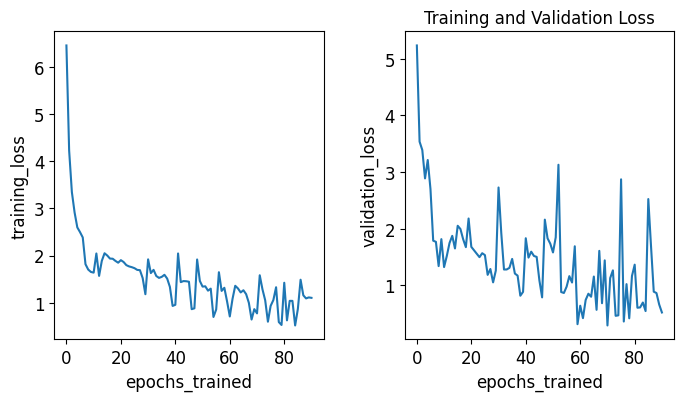

In [16]:
fig, axes = plot_summary(
    inference1, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [17]:
theta1_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta1_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta1_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta1_500.shape, theta1_2000.shape, theta1_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [19]:
target_x_poly = np.hstack([x_500_SB**i for i in range(1, 5)])
pred_obs = model.predict(target_x_poly)
x_obs_numpy = np.hstack([pred_obs, x_500_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)


for i in range(100):
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta1_500[i, :, :] = theta_post.cpu().numpy()

In [20]:
target_x_poly = np.hstack([x_2000_SB**i for i in range(1, 5)])
pred_obs = model.predict(target_x_poly)
x_obs_numpy = np.hstack([pred_obs, x_2000_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta1_2000[i, :, :] = theta_post.cpu().numpy()

In [21]:
target_x_poly = np.hstack([x_6000_SB**i for i in range(1, 5)])
pred_obs = model.predict(target_x_poly)
x_obs_numpy = np.hstack([pred_obs, x_6000_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta1_6000[i, :, :] = theta_post.cpu().numpy()

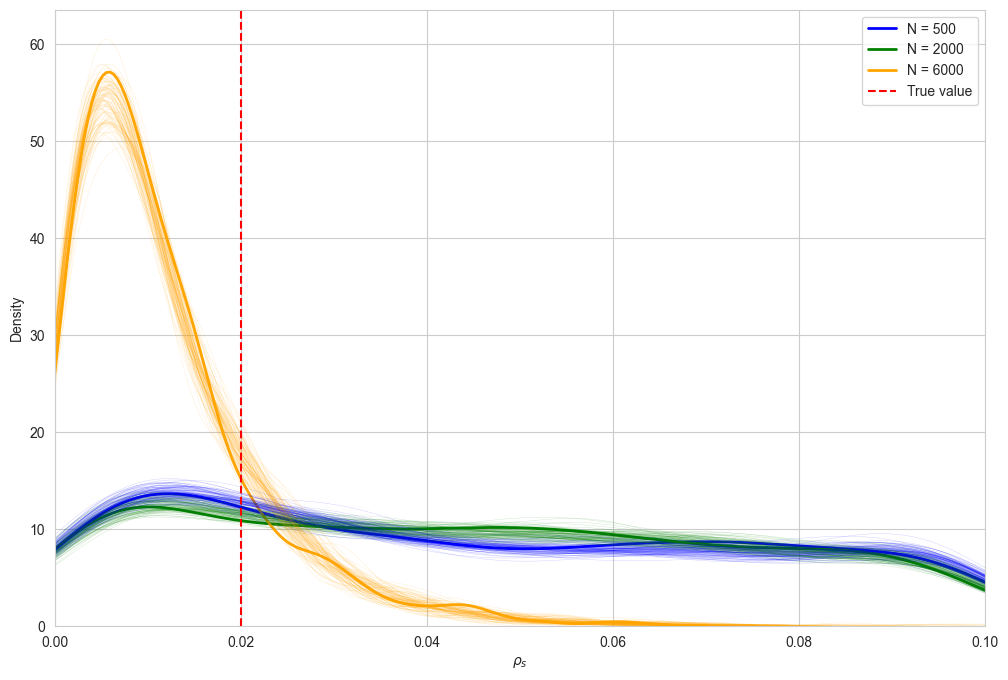

In [22]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

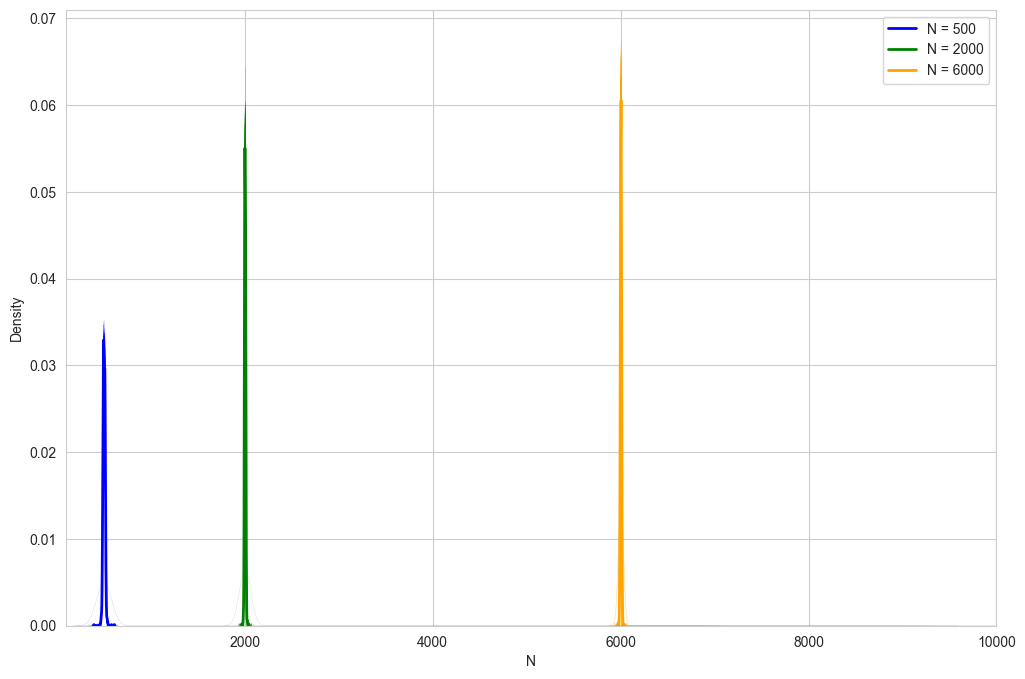

In [23]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

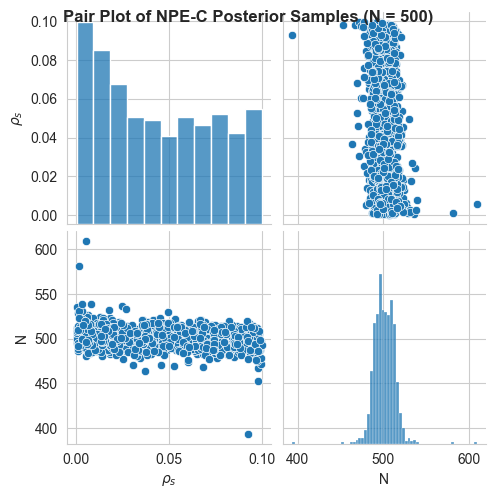

In [24]:
df_500 = pd.DataFrame(theta1_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

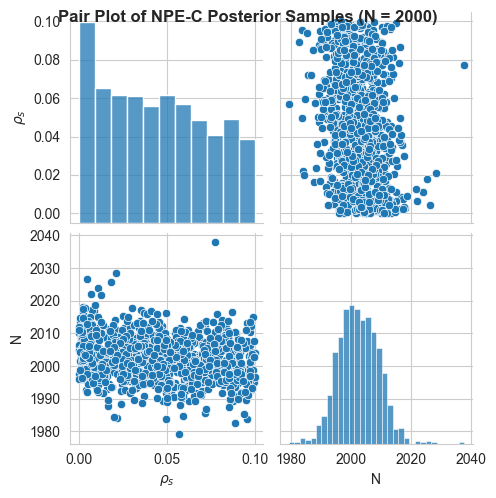

In [25]:
df_2000 = pd.DataFrame(theta1_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

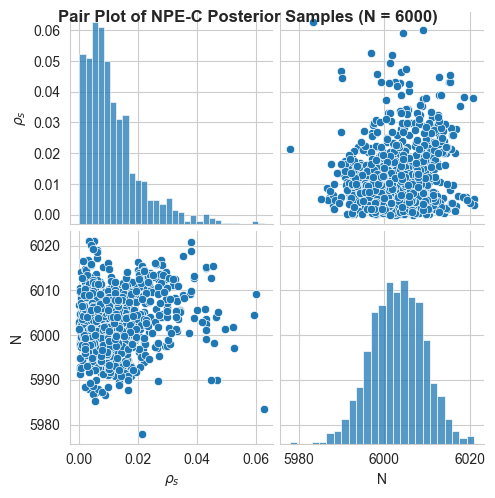

In [26]:
df_6000 = pd.DataFrame(theta1_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [27]:
theta1_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta1_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta1_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta1_500_CO.shape, theta1_2000_CO.shape, theta1_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [28]:
target_x_poly = np.hstack([x_500_CO**i for i in range(1, 5)])
pred_obs = model.predict(target_x_poly)
x_obs_numpy = np.hstack([pred_obs, x_500_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta1_500_CO[i, :, :] = theta_post.cpu().numpy()

In [29]:
target_x_poly = np.hstack([x_2000_CO**i for i in range(1, 5)])
pred_obs = model.predict(target_x_poly)
x_obs_numpy = np.hstack([pred_obs, x_2000_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta1_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [30]:
target_x_poly = np.hstack([x_6000_CO**i for i in range(1, 5)])
pred_obs = model.predict(target_x_poly)
x_obs_numpy = np.hstack([pred_obs, x_6000_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta1_6000_CO[i, :, :] = theta_post.cpu().numpy()

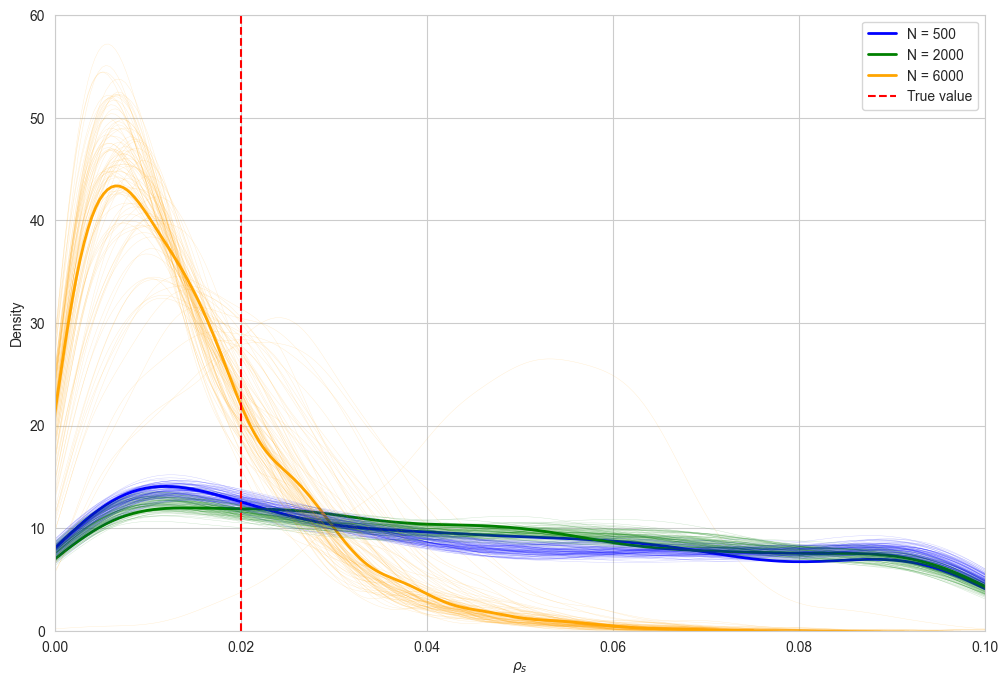

In [31]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

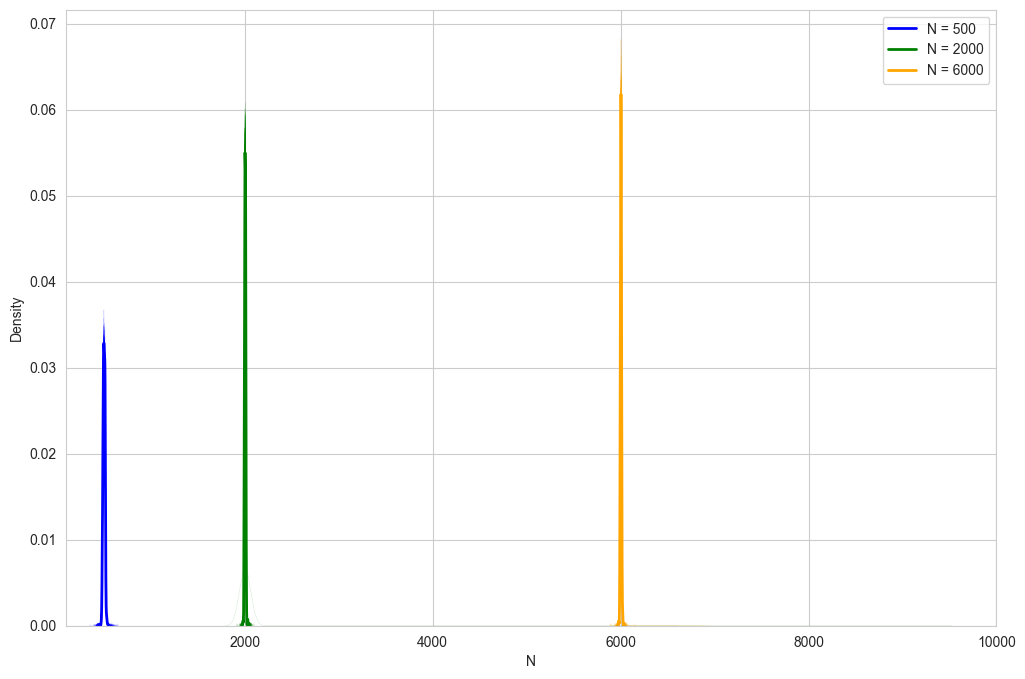

In [32]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

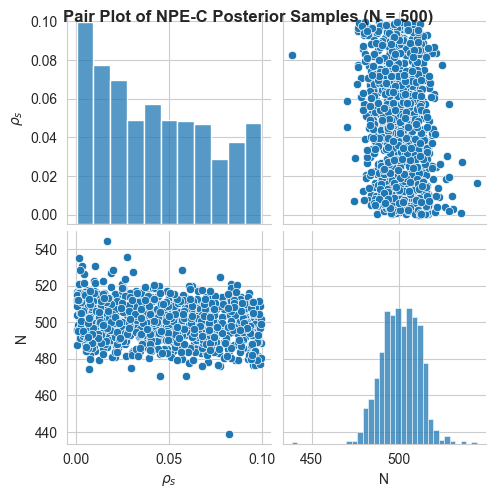

In [33]:
df_500 = pd.DataFrame(theta1_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

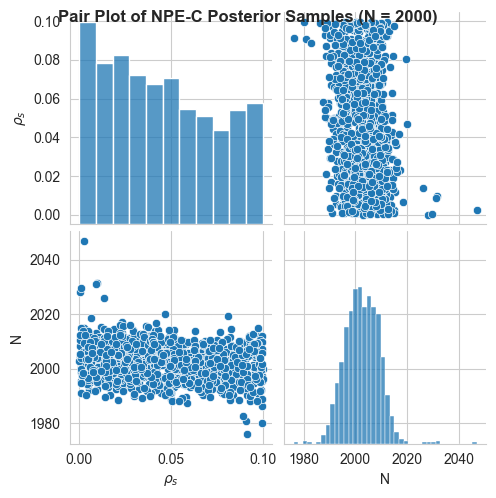

In [34]:
df_2000 = pd.DataFrame(theta1_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

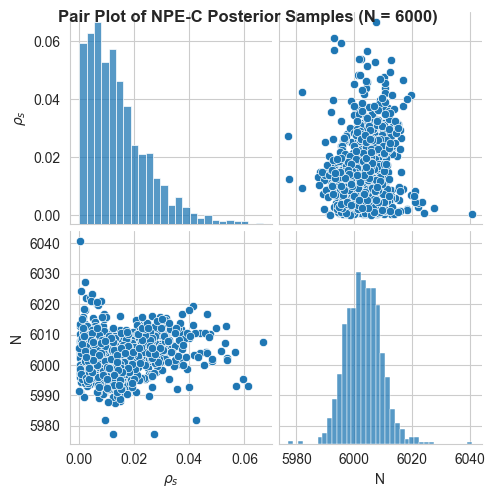

In [35]:
df_6000 = pd.DataFrame(theta1_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

In [36]:
df.loc[30, rho_cols] = evaluate_posterior_metrics(0.02, theta1_500[:, :, 0])
df.loc[30, L_cols] = evaluate_posterior_metrics(500, theta1_500[:, :, 1])

df.loc[31, rho_cols] = evaluate_posterior_metrics(0.02, theta1_2000[:, :, 0])
df.loc[31, L_cols] = evaluate_posterior_metrics(2000, theta1_2000[:, :, 1])

df.loc[32, rho_cols] = evaluate_posterior_metrics(0.02, theta1_6000[:, :, 0])
df.loc[32, L_cols] = evaluate_posterior_metrics(6000, theta1_6000[:, :, 1])

df.loc[33, rho_cols] = evaluate_posterior_metrics(0.02, theta1_500_CO[:, :, 0])
df.loc[33, L_cols] = evaluate_posterior_metrics(500, theta1_500_CO[:, :, 1])

df.loc[34, rho_cols] = evaluate_posterior_metrics(0.02, theta1_2000_CO[:, :, 0])
df.loc[34, L_cols] = evaluate_posterior_metrics(2000, theta1_2000_CO[:, :, 1])

df.loc[35, rho_cols] = evaluate_posterior_metrics(0.02, theta1_6000_CO[:, :, 0])
df.loc[35, L_cols] = evaluate_posterior_metrics(6000, theta1_6000_CO[:, :, 1])

### Generalized Additive Models (GAM)

Consider the GAM equation
$$
y_i = \beta_0 + \sum_{j=1}^n f_j(x_{ij}) + \epsilon_i,
$$
take $\hat\beta_0 + \sum_{j=1}^n f_j(x_j)$ as the summary statistics.

In [37]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference2 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [38]:
degrees_of_freedom = [5] * 46 
polynomial_degrees = [3] * 46

spline_basis = BSplines(x_numpy, df=degrees_of_freedom, degree=polynomial_degrees)
exog_linear = pd.DataFrame({'const': np.ones(x_numpy.shape[0])})

penalty_weights = np.array([1.0] * 46)
gam_model = GLMGam(endog=theta_numpy[:, 0:1], exog=exog_linear, smoother=spline_basis, alpha=penalty_weights)

gam_results = gam_model.fit()

print(gam_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                20000
Model:                         GLMGam   Df Residuals:                 19881.65
Model Family:                Gaussian   Df Model:                       117.35
Link Function:               Identity   Scale:                      4.6475e-05
Method:                         PIRLS   Log-Likelihood:                 71446.
Date:                Mon, 15 Jun 2026   Deviance:                      0.92401
Time:                        12:00:40   Pearson chi2:                    0.924
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1742     36.469     -0.032      0.9

In [39]:
pred_gam = gam_results.predict()
x2_numpy = np.hstack([pred_gam.reshape(-1, 1), theta_numpy[:, 1:2]])
x2 = torch.tensor(x2_numpy, device=torch_device)
x2 = x2.to(torch.float32)

x2.shape, x2.dtype

(torch.Size([20000, 2]), torch.float32)

In [40]:
density_estimator2 = inference2.append_simulations(theta, x2).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior2 = inference2.build_posterior(density_estimator2)

 Neural network successfully converged after 61 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-15T12_00_36.210909' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


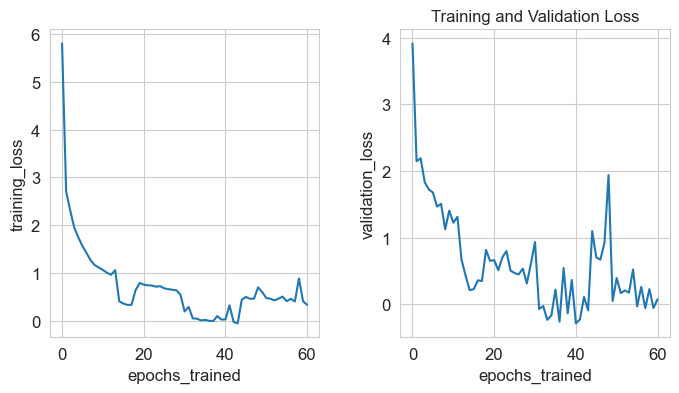

In [41]:
fig, axes = plot_summary(
    inference2, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [42]:
theta2_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta2_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta2_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta2_500.shape, theta2_2000.shape, theta2_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [43]:
new_exog_linear = pd.DataFrame({'const': np.ones(x_500_SB.shape[0])})
pred_obs = gam_results.predict(exog=new_exog_linear, exog_smooth=x_500_SB)
x_obs_numpy = np.hstack([pred_obs.reshape(-1, 1), x_500_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta2_500[i, :, :] = theta_post.cpu().numpy()

NotImplementedError: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)

In [44]:
new_exog_linear = pd.DataFrame({'const': np.ones(x_2000_SB.shape[0])})
pred_obs = gam_results.predict(exog=new_exog_linear, exog_smooth=x_2000_SB)
x_obs_numpy = np.hstack([pred_obs.reshape(-1, 1), x_2000_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta2_2000[i, :, :] = theta_post.cpu().numpy()

In [45]:
new_exog_linear = pd.DataFrame({'const': np.ones(x_6000_SB.shape[0])})
pred_obs = gam_results.predict(exog=new_exog_linear, exog_smooth=x_6000_SB)
x_obs_numpy = np.hstack([pred_obs.reshape(-1, 1), x_6000_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta2_6000[i, :, :] = theta_post.cpu().numpy()

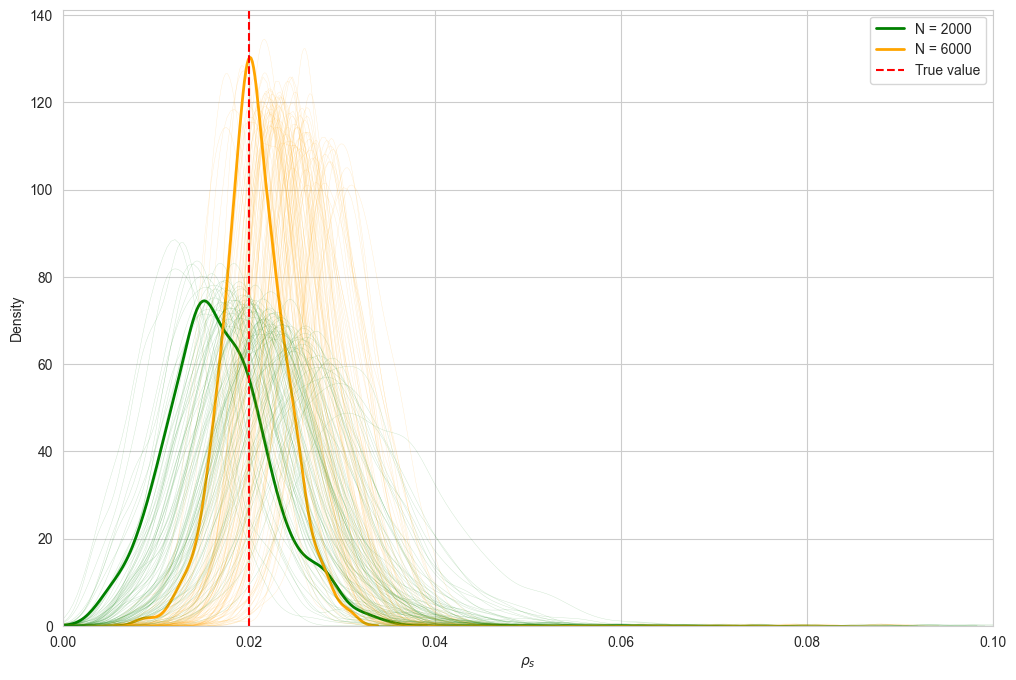

In [46]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
# sns.kdeplot(theta2_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    # sns.kdeplot(theta2_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

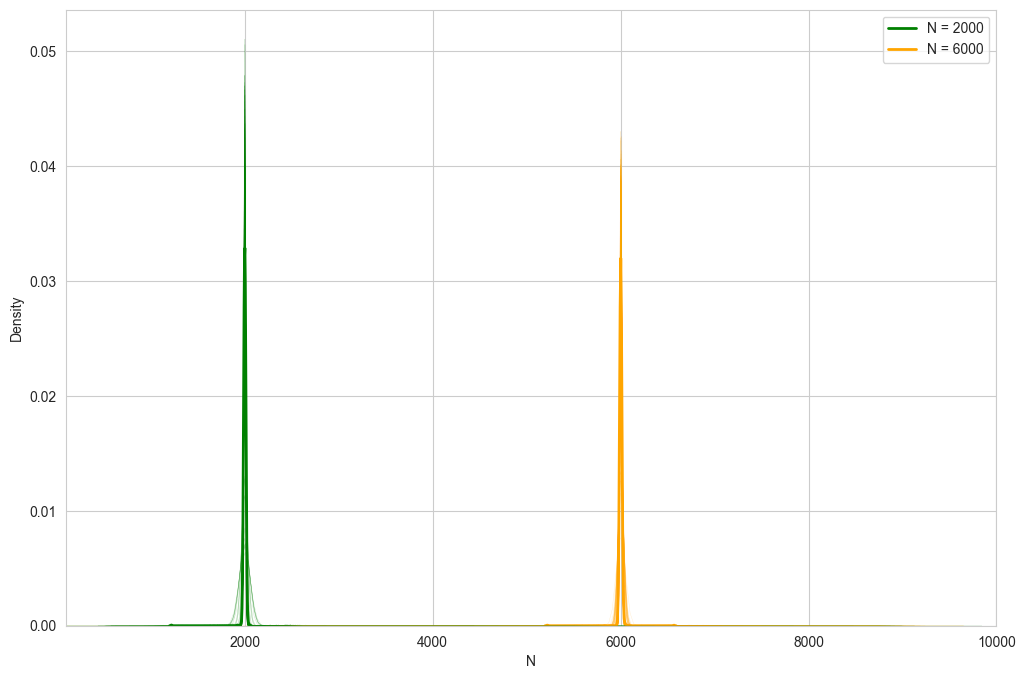

In [47]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
# sns.kdeplot(theta2_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    # sns.kdeplot(theta2_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

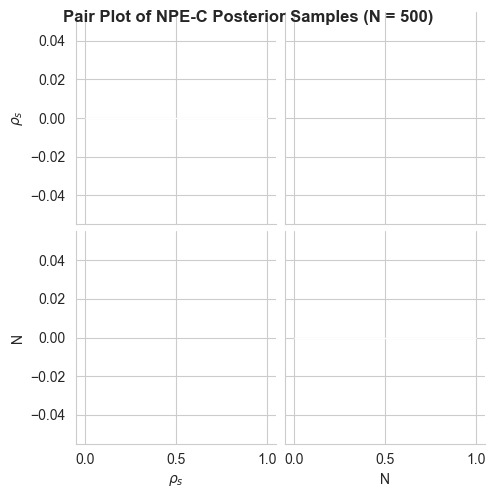

In [48]:
df_500 = pd.DataFrame(theta2_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

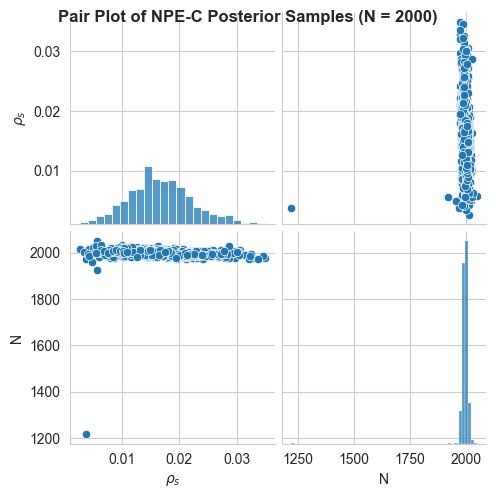

In [49]:
df_2000 = pd.DataFrame(theta2_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

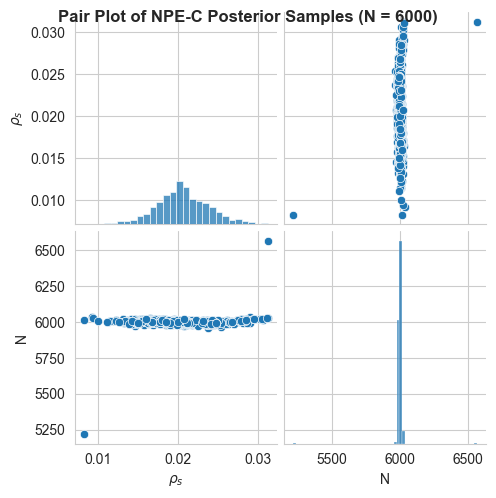

In [50]:
df_6000 = pd.DataFrame(theta2_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [51]:
theta2_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta2_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta2_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta2_500_CO.shape, theta2_2000_CO.shape, theta2_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [52]:
new_exog_linear = pd.DataFrame({'const': np.ones(x_500_CO.shape[0])})
pred_obs = gam_results.predict(exog=new_exog_linear, exog_smooth=x_500_CO)
x_obs_numpy = np.hstack([pred_obs.reshape(-1, 1), x_500_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta2_500_CO[i, :, :] = theta_post.cpu().numpy()

In [53]:
new_exog_linear = pd.DataFrame({'const': np.ones(x_2000_CO.shape[0])})
pred_obs = gam_results.predict(exog=new_exog_linear, exog_smooth=x_2000_CO)
x_obs_numpy = np.hstack([pred_obs.reshape(-1, 1), x_2000_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta2_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [54]:
new_exog_linear = pd.DataFrame({'const': np.ones(x_6000_CO.shape[0])})
pred_obs = gam_results.predict(exog=new_exog_linear, exog_smooth=x_6000_CO)
x_obs_numpy = np.hstack([pred_obs.reshape(-1, 1), x_6000_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta2_6000_CO[i, :, :] = theta_post.cpu().numpy()

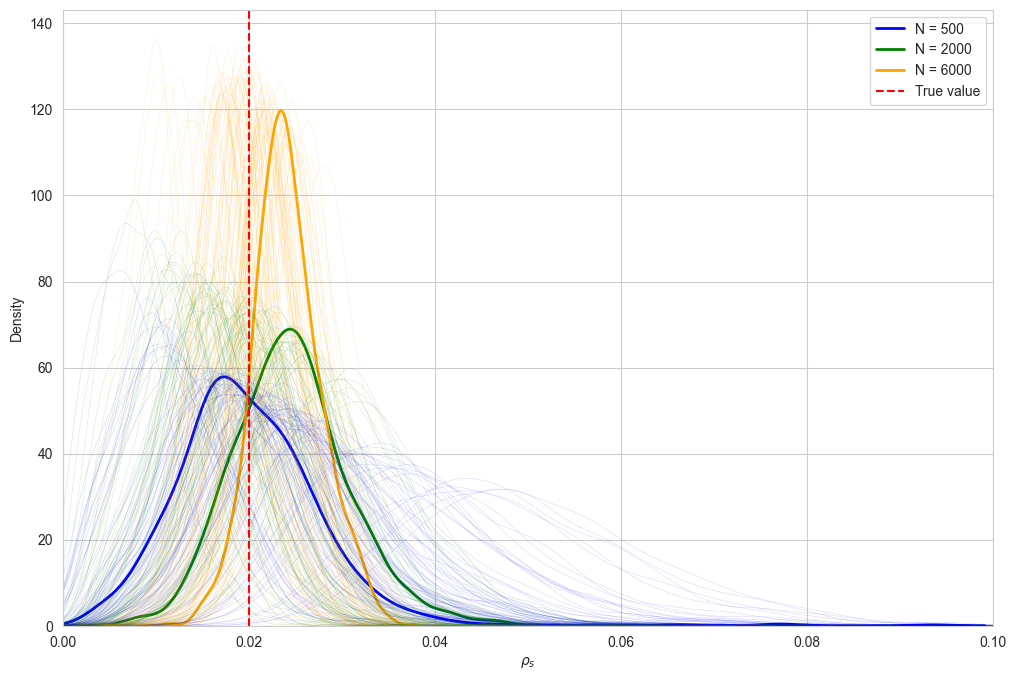

In [55]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

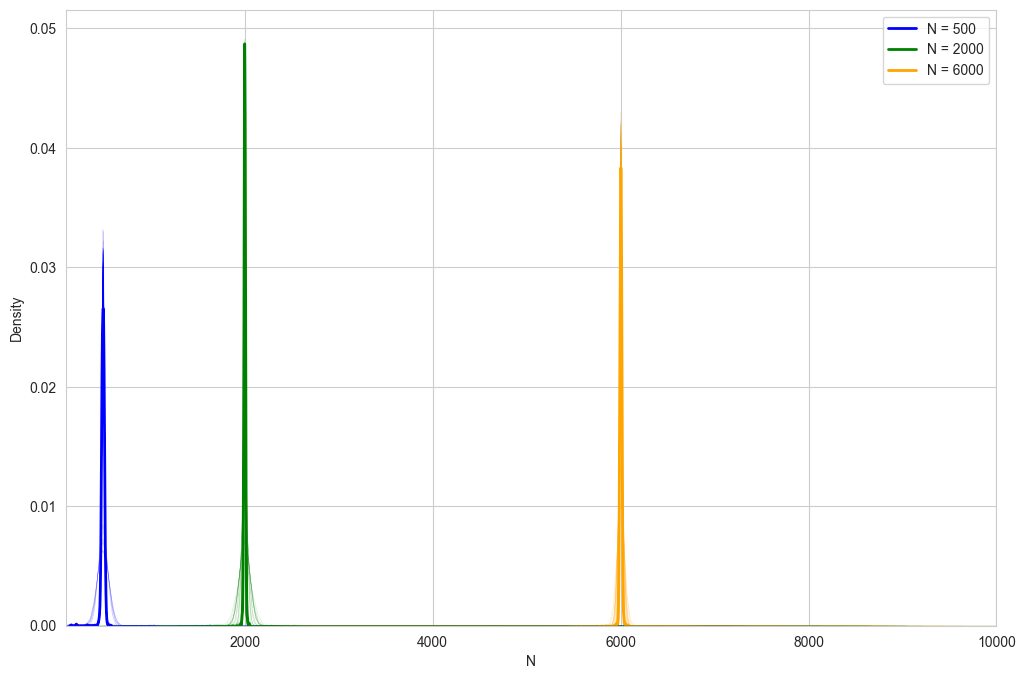

In [56]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

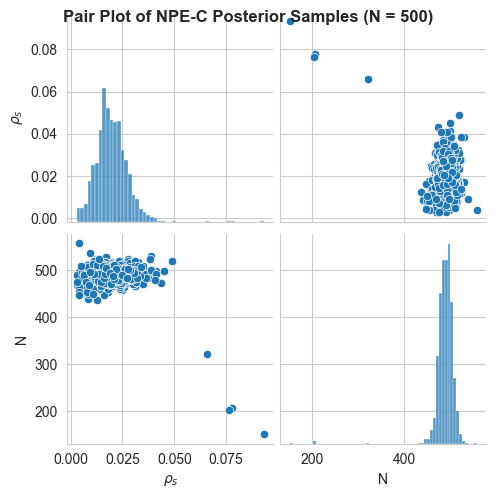

In [57]:
df_500 = pd.DataFrame(theta2_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

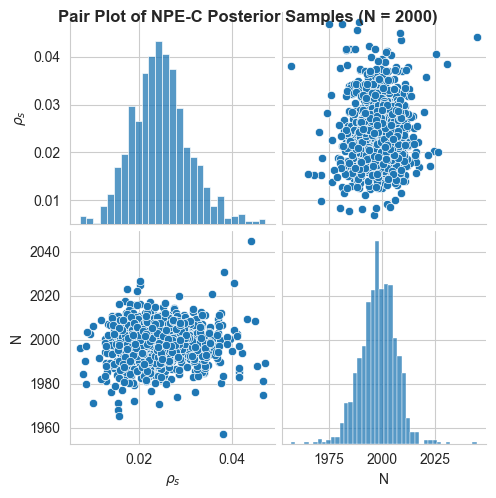

In [58]:
df_2000 = pd.DataFrame(theta2_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

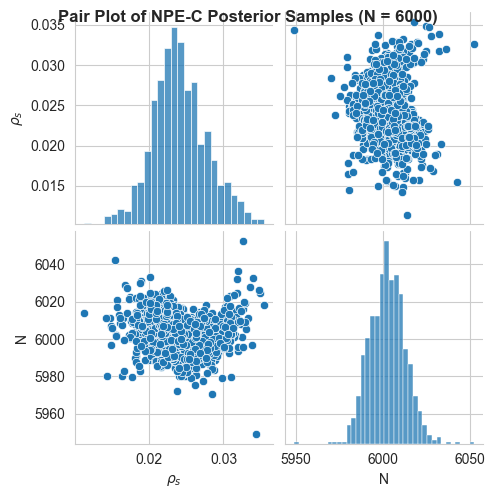

In [59]:
df_6000 = pd.DataFrame(theta2_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

In [61]:
# df.loc[36, rho_cols] = evaluate_posterior_metrics(0.02, theta2_500[:, :, 0])
# df.loc[36, L_cols] = evaluate_posterior_metrics(500, theta2_500[:, :, 1])

df.loc[37, rho_cols] = evaluate_posterior_metrics(0.02, theta2_2000[:, :, 0])
df.loc[37, L_cols] = evaluate_posterior_metrics(2000, theta2_2000[:, :, 1])

df.loc[38, rho_cols] = evaluate_posterior_metrics(0.02, theta2_6000[:, :, 0])
df.loc[38, L_cols] = evaluate_posterior_metrics(6000, theta2_6000[:, :, 1])

df.loc[39, rho_cols] = evaluate_posterior_metrics(0.02, theta2_500_CO[:, :, 0])
df.loc[39, L_cols] = evaluate_posterior_metrics(500, theta2_500_CO[:, :, 1])

df.loc[40, rho_cols] = evaluate_posterior_metrics(0.02, theta2_2000_CO[:, :, 0])
df.loc[40, L_cols] = evaluate_posterior_metrics(2000, theta2_2000_CO[:, :, 1])

df.loc[41, rho_cols] = evaluate_posterior_metrics(0.02, theta2_6000_CO[:, :, 0])
df.loc[41, L_cols] = evaluate_posterior_metrics(6000, theta2_6000_CO[:, :, 1])

### Neural Network

Train a neural network such that
$$
y_i = \text{NN}_\psi (\bf{x_i}),
$$
and use $\text{NN}_{\hat\psi} (\bf{x})$ as the summary statistics.

In [62]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference3 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [63]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_numpy)

model = Sequential([                                 # input layer - 46 features
    Dense(64, activation='relu', input_shape=(46,)), # layer 1 - 64 neurons
    Dense(32, activation='relu'),                    # layer 2 - 32 neurons
    Dense(1)                                         # output layer - 1 neuron
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    x_scaled, 
    theta_numpy[:, 0:1],
    epochs=80, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1 # Shows a progress bar
)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0321 - mae: 0.0794 - val_loss: 0.0018 - val_mae: 0.0280
Epoch 2/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0013 - mae: 0.0242 - val_loss: 9.4425e-04 - val_mae: 0.0220
Epoch 3/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0014 - mae: 0.0211 - val_loss: 5.7605e-04 - val_mae: 0.0170
Epoch 4/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0059 - mae: 0.0188 - val_loss: 0.0013 - val_mae: 0.0254
Epoch 5/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0040 - mae: 0.0242 - val_loss: 4.5036e-04 - val_mae: 0.0154
Epoch 6/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step - loss: 4.6267e-04 - mae: 0.0149 - val_loss: 4.7684e-04 - val_mae: 0.0157
Epoch 7/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.9592e-04 - mae: 0.0131 - val_loss: 3.1034e-04 - val_mae: 0.0126
Epoch 8/80
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0043 - mae: 0.0180 - val_loss: 2.4217e-04 - val_mae: 0.0116
Epoch 9/80
500/500 ━━━

In [64]:
pred_nn = model.predict(x_scaled)
x3_numpy = np.hstack([pred_nn, theta_numpy[:, 1:2]])
x3 = torch.tensor(x3_numpy, device=torch_device)
x3 = x3.to(torch.float32)

x3.shape, x3.dtype

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step


(torch.Size([20000, 2]), torch.float32)

In [65]:
density_estimator3 = inference3.append_simulations(theta, x3).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior3 = inference3.build_posterior(density_estimator3)

 Neural network successfully converged after 31 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-15T12_05_12.128519' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


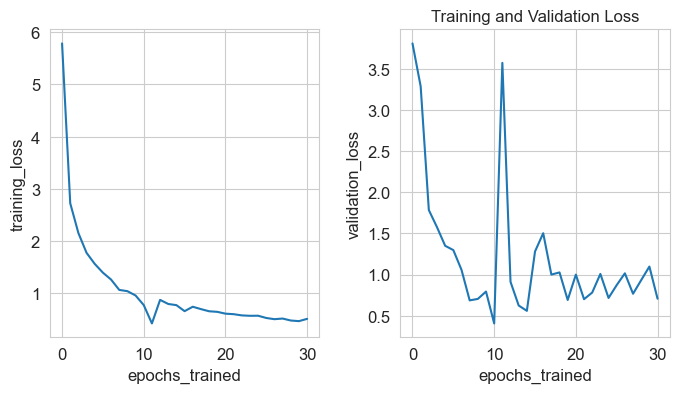

In [66]:
fig, axes = plot_summary(
    inference3, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [67]:
theta3_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta3_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta3_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta3_500.shape, theta3_2000.shape, theta3_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [68]:
x_new_scaled = scaler.transform(x_500_SB)
pred_obs = model.predict(x_new_scaled)
x_obs_numpy = np.hstack([pred_obs, x_500_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta3_500[i, :, :] = theta_post.cpu().numpy()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [69]:
x_new_scaled = scaler.transform(x_2000_SB)
pred_obs = model.predict(x_new_scaled)
x_obs_numpy = np.hstack([pred_obs, x_2000_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta3_2000[i, :, :] = theta_post.cpu().numpy()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [70]:
x_new_scaled = scaler.transform(x_6000_SB)
pred_obs = model.predict(x_new_scaled)
x_obs_numpy = np.hstack([pred_obs, x_6000_SB[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta3_6000[i, :, :] = theta_post.cpu().numpy()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


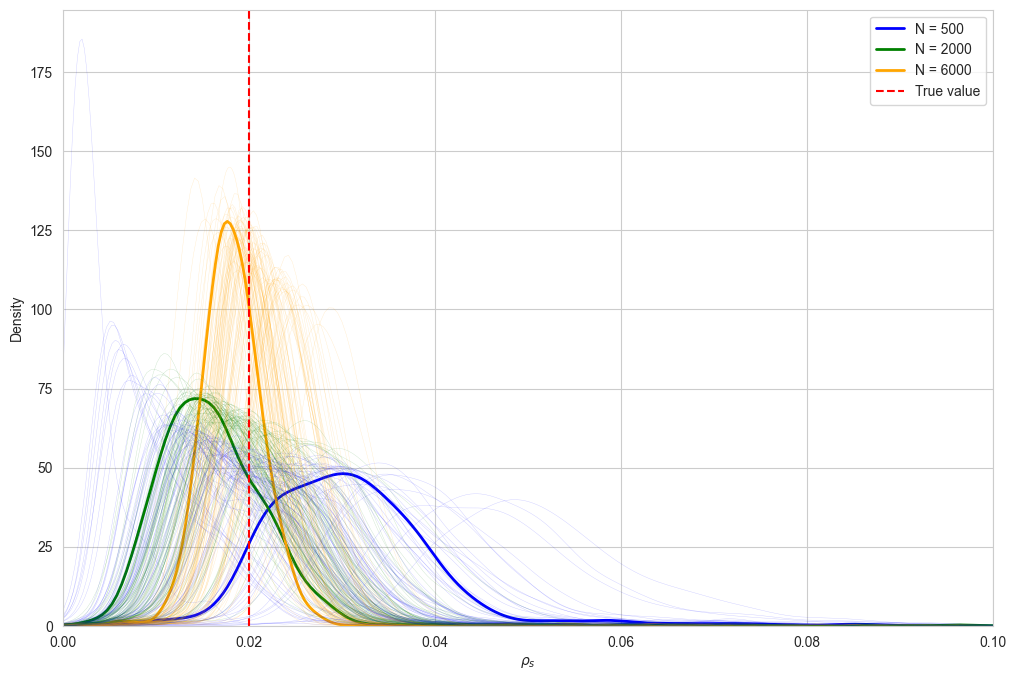

In [71]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

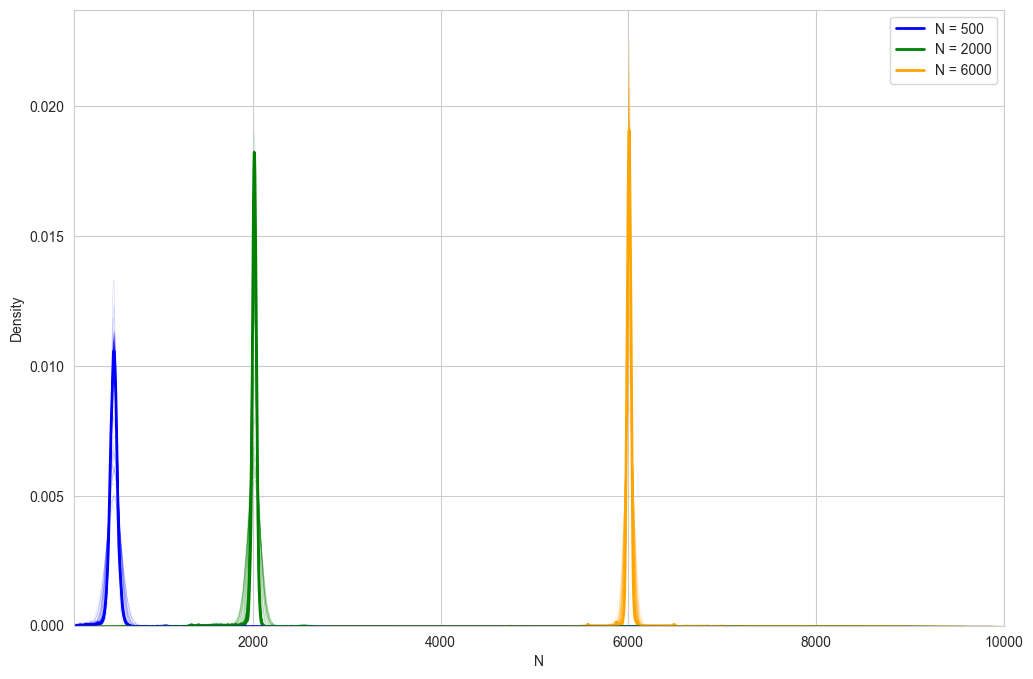

In [72]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

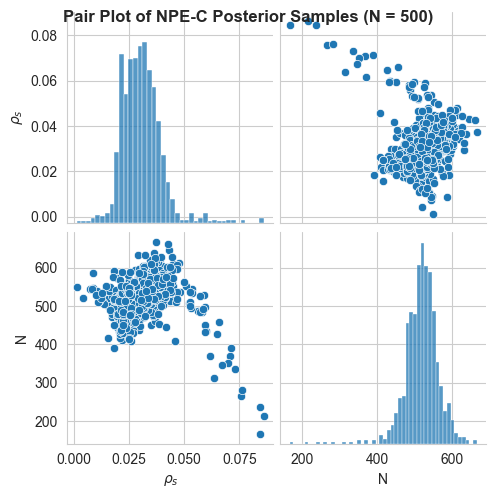

In [73]:
df_500 = pd.DataFrame(theta3_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

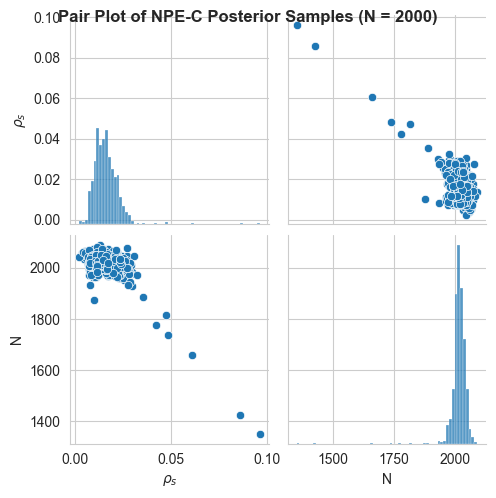

In [74]:
df_2000 = pd.DataFrame(theta3_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

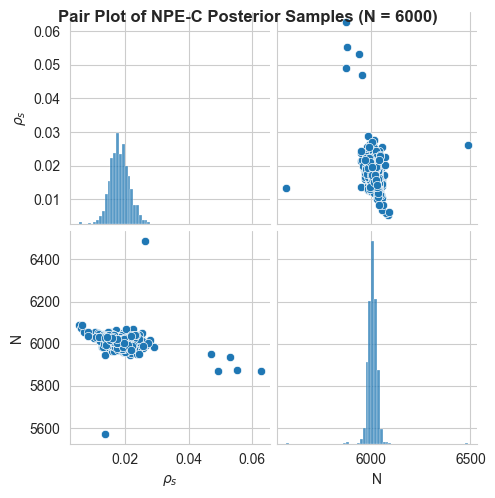

In [75]:
df_6000 = pd.DataFrame(theta3_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [76]:
theta3_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta3_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta3_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta3_500_CO.shape, theta3_2000_CO.shape, theta3_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [77]:
x_new_scaled = scaler.transform(x_500_CO)
pred_obs = model.predict(x_new_scaled)
x_obs_numpy = np.hstack([pred_obs, x_500_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta3_500_CO[i, :, :] = theta_post.cpu().numpy()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [78]:
x_new_scaled = scaler.transform(x_2000_CO)
pred_obs = model.predict(x_new_scaled)
x_obs_numpy = np.hstack([pred_obs, x_2000_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta3_2000_CO[i, :, :] = theta_post.cpu().numpy()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [79]:
x_new_scaled = scaler.transform(x_6000_CO)
pred_obs = model.predict(x_new_scaled)
x_obs_numpy = np.hstack([pred_obs, x_6000_CO[:, -1].reshape(-1, 1)])
x_obs = torch.tensor(x_obs_numpy, device=torch_device)
x_obs = x_obs.to(torch.float32)

for i in range(100):
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[i, :], show_progress_bars=False)
    theta3_6000_CO[i, :, :] = theta_post.cpu().numpy()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


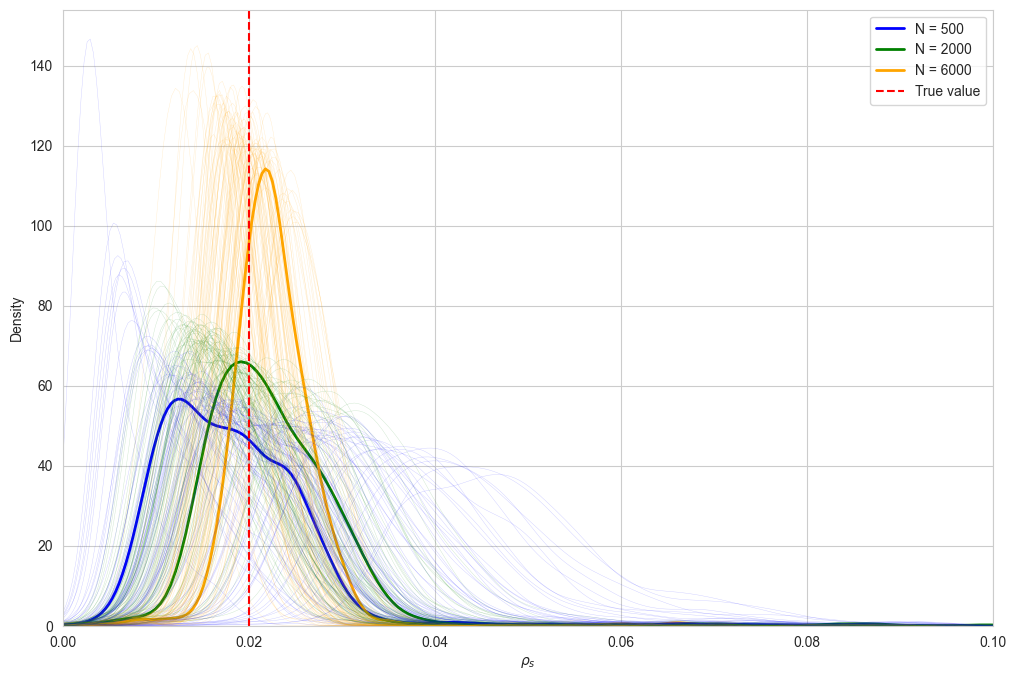

In [80]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

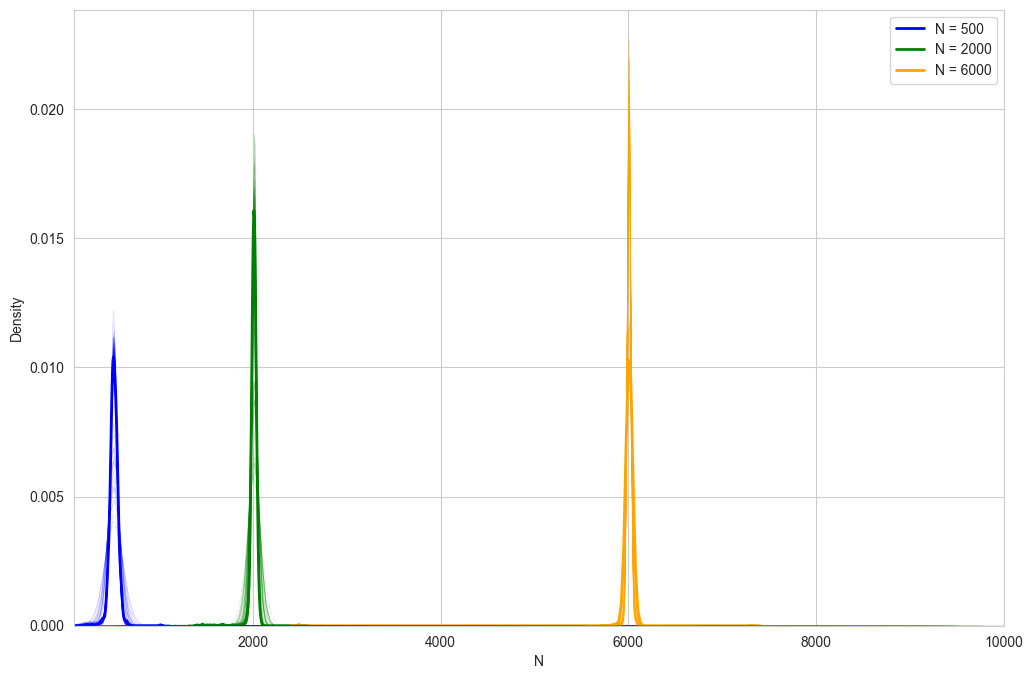

In [81]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

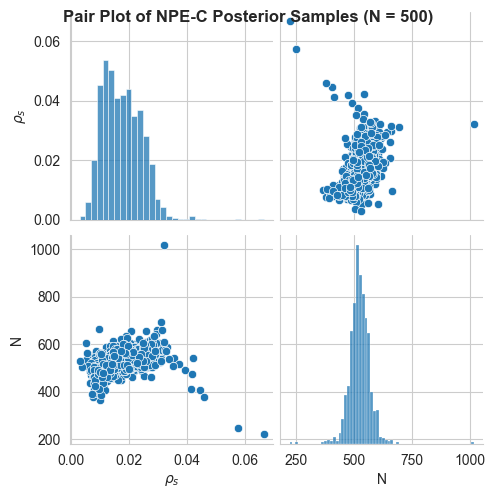

In [82]:
df_500 = pd.DataFrame(theta3_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

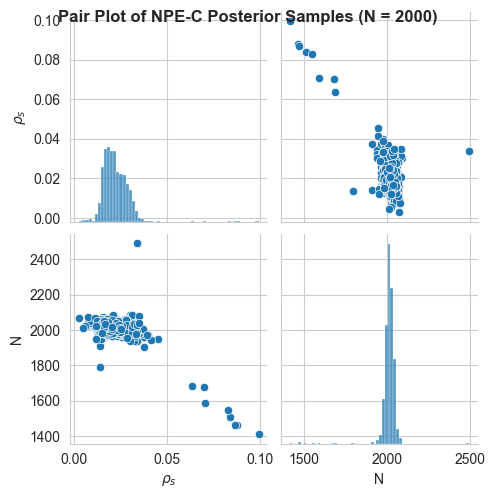

In [83]:
df_2000 = pd.DataFrame(theta3_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

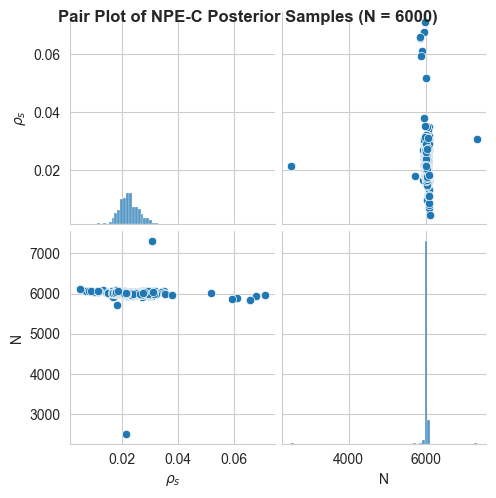

In [84]:
df_6000 = pd.DataFrame(theta3_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

In [85]:
df.loc[42, rho_cols] = evaluate_posterior_metrics(0.02, theta3_500[:, :, 0])
df.loc[42, L_cols] = evaluate_posterior_metrics(500, theta3_500[:, :, 1])

df.loc[43, rho_cols] = evaluate_posterior_metrics(0.02, theta3_2000[:, :, 0])
df.loc[43, L_cols] = evaluate_posterior_metrics(2000, theta3_2000[:, :, 1])

df.loc[44, rho_cols] = evaluate_posterior_metrics(0.02, theta3_6000[:, :, 0])
df.loc[44, L_cols] = evaluate_posterior_metrics(6000, theta3_6000[:, :, 1])

df.loc[45, rho_cols] = evaluate_posterior_metrics(0.02, theta3_500_CO[:, :, 0])
df.loc[45, L_cols] = evaluate_posterior_metrics(500, theta3_500_CO[:, :, 1])

df.loc[46, rho_cols] = evaluate_posterior_metrics(0.02, theta3_2000_CO[:, :, 0])
df.loc[46, L_cols] = evaluate_posterior_metrics(2000, theta3_2000_CO[:, :, 1])

df.loc[47, rho_cols] = evaluate_posterior_metrics(0.02, theta3_6000_CO[:, :, 0])
df.loc[47, L_cols] = evaluate_posterior_metrics(6000, theta3_6000_CO[:, :, 1])

In [86]:
df.to_csv('../output/sbi_metric_table.csv', index=False)